In [152]:
import json
from pathlib import Path
from typing import Dict, Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 200)

In [153]:
# BASE_DIR = Path("../assets/experiments/2026-03-10_21-07-34")
BASE_DIR = Path("../assets/experiments/2026-03-11_10-48-53__5-15_secs")

BALANCER_DIR = BASE_DIR / "baseline"
REPL_NO_ADAPT_DIR = BASE_DIR / "non_adaptive"
REPL_ADAPT_DIR = BASE_DIR / "adaptive"

print(BASE_DIR)

..\assets\experiments\2026-03-11_10-48-53__5-15_secs


In [154]:
def load_experiment(path: Path) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [155]:
def extract_method(data):
    factors = data["factors"]

    balancer = factors.get("balancer")
    replication = factors.get("replication")
    adaptive = factors.get("adaptive")

    if replication:
        return f"{balancer} | {replication} | {'adaptive' if adaptive else 'no_adaptive'}"

    return f"{balancer} | no_replication"

In [156]:
def flatten_requests(data, method, group):
    rows = []

    for req in data["requests"]:

        upstream = req.get("upstream", {})
        signals = req.get("signals", {})

        sockets = upstream.get("sockets", [])
        winner = upstream.get("winner_socket")

        if sockets:
            replicas = len(sockets)
        else:
            replicas = 1

        rows.append({
            "method": method,
            "group": group,

            "req_id": req["req_id"],
            "endpoint": req["endpoint"],

            "latency_ms": req["latency_ms"],
            "status": req["status"],
            "ok": req["ok"],

            "winner_socket": winner,
            "replicas": replicas,

            "cpu_util": signals.get("cpu_util"),
            "mem_util": signals.get("mem_util"),
            "cpu_burn": signals.get("cpu_burn"),
            "mem_burn": signals.get("mem_burn"),
        })

    return pd.DataFrame(rows)

In [157]:
def load_folder(folder, group):
    dfs = []

    for file in folder.glob("*.json"):
        data = load_experiment(file)

        method = extract_method(data)

        df = flatten_requests(data, method, group)

        dfs.append(df)

    return dfs


dfs = []

dfs += load_folder(BALANCER_DIR, "balancer_only")
dfs += load_folder(REPL_NO_ADAPT_DIR, "replication_no_adaptive")
dfs += load_folder(REPL_ADAPT_DIR, "replication_adaptive")

df = pd.concat(dfs, ignore_index=True)

df.head()

,method,group,req_id,endpoint,latency_ms,status,ok,winner_socket,replicas,cpu_util,mem_util,cpu_burn,mem_burn
0,airm | no_replication,balancer_only,req-0,mem?seconds=7&mb=75,7253.0839,200,True,None,1,34.5,19.6,None,True
1,airm | no_replication,balancer_only,req-1,mem?seconds=9&mb=75,9286.2509,200,True,None,1,33.7,19.4,None,True
2,airm | no_replication,balancer_only,req-2,mem?seconds=7&mb=75,7209.3076,200,True,None,1,34.9,19.6,None,True
3,airm | no_replication,balancer_only,req-3,cpu?seconds=10,10061.6139,200,True,None,1,32.8,19.5,True,None
4,airm | no_replication,balancer_only,req-4,mem?seconds=10&mb=75,10148.5764,200,True,None,1,29.2,19.3,None,True


In [158]:
def p50(x):
    return np.percentile(x, 50)


def p95(x):
    return np.percentile(x, 95)


def p99(x):
    return np.percentile(x, 99)

# Latency

In [159]:
latency_stats = (
    df
    .groupby("method")["latency_ms"]
    .agg(
        mean="mean",
        p50=p50,
        p95=p95,
        p99=p99
    )
    .sort_values("mean")
)

latency_stats

,mean,p50,p95,p99
method,,,,
airm | speculative | adaptive,10631.600194,10420.99405,15840.482125,19506.495569
topsis | speculative | adaptive,10744.760576,10441.83045,16001.994530,19197.588084
topsis | hedged | adaptive,10842.537632,10440.36995,16913.893710,18406.312112
electre | speculative | adaptive,11013.309655,11053.49940,16567.097420,19444.996984
electre | hedged | adaptive,11110.747933,11079.83405,17600.159395,19515.273578
airm | hedged | adaptive,11171.955242,11126.21190,16947.179070,19529.345637
electre | no_replication,11514.945413,11084.17295,18514.574915,26602.701451
topsis | no_replication,11812.334195,11252.73550,19826.170905,24873.667949
airm | no_replication,12036.576335,11235.78235,20863.604225,30364.371181


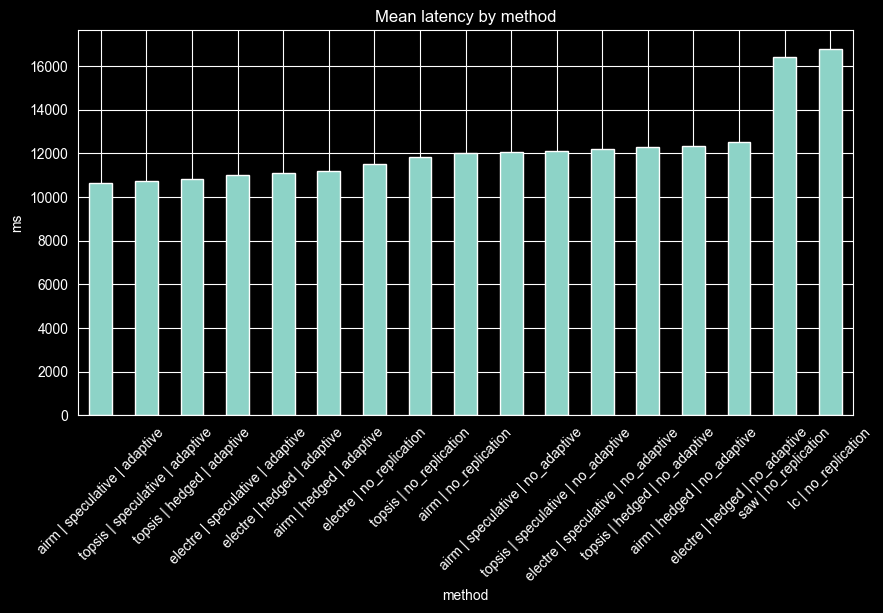

In [160]:
latency_stats["mean"].plot(kind="bar")

plt.title("Mean latency by method")
plt.ylabel("ms")
plt.xticks(rotation=45)

plt.show()

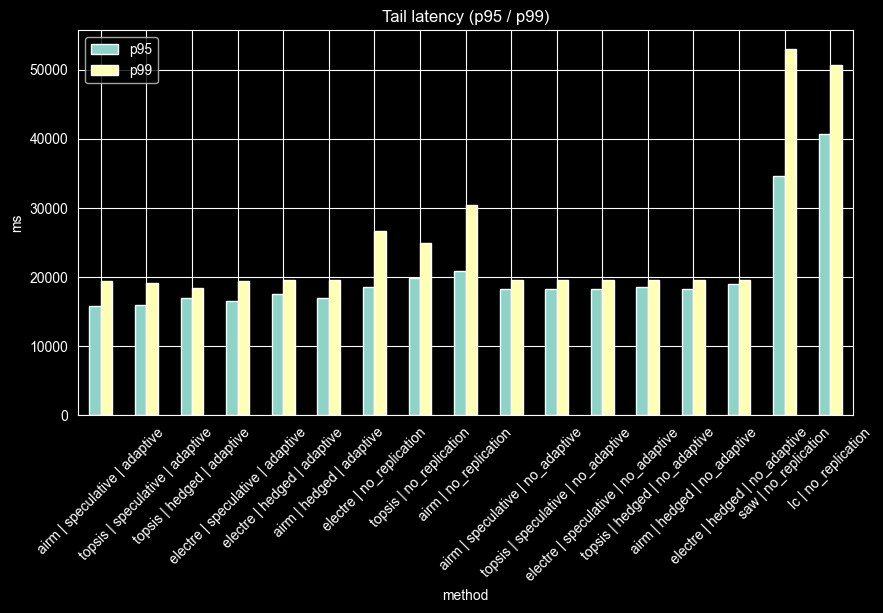

In [161]:
latency_stats[["p95", "p99"]].plot(kind="bar")

plt.title("Tail latency (p95 / p99)")
plt.ylabel("ms")
plt.xticks(rotation=45)

plt.show()

# WA

In [162]:
wa_stats = (
    df
    .groupby("method")["replicas"]
    .agg(
        mean="mean",
        p95=p95,
        max="max"
    )
    .sort_values("mean")
)

wa_stats

,mean,p95,max
method,,,
airm | no_replication,1.000,1.0,1
electre | no_replication,1.000,1.0,1
lc | no_replication,1.000,1.0,1
saw | no_replication,1.000,1.0,1
topsis | no_replication,1.000,1.0,1
topsis | speculative | adaptive,1.446,3.0,3
topsis | hedged | adaptive,1.468,3.0,3
electre | speculative | adaptive,1.531,3.0,3
electre | hedged | adaptive,1.548,3.0,3


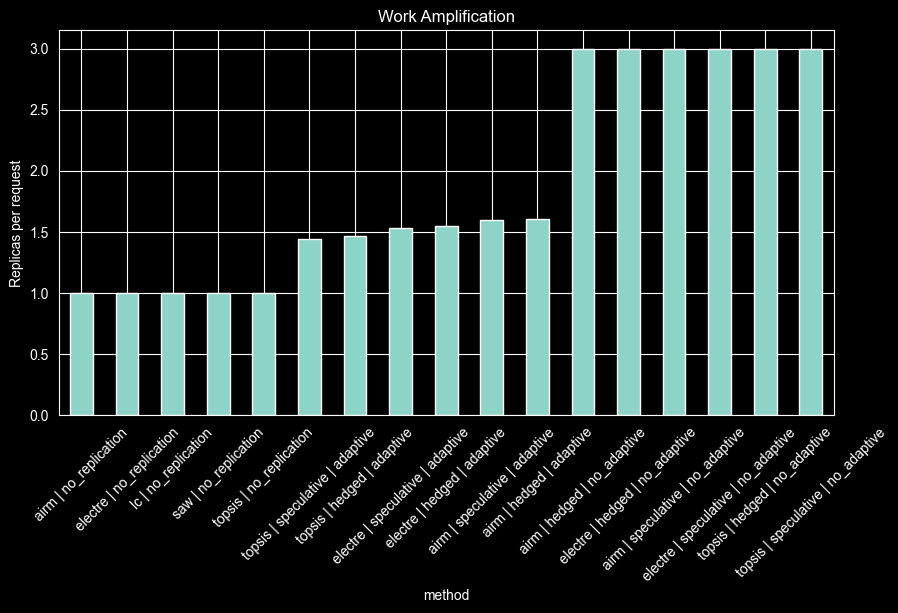

In [163]:
wa_stats["mean"].plot(kind="bar")

plt.title("Work Amplification")
plt.ylabel("Replicas per request")

plt.xticks(rotation=45)

plt.show()

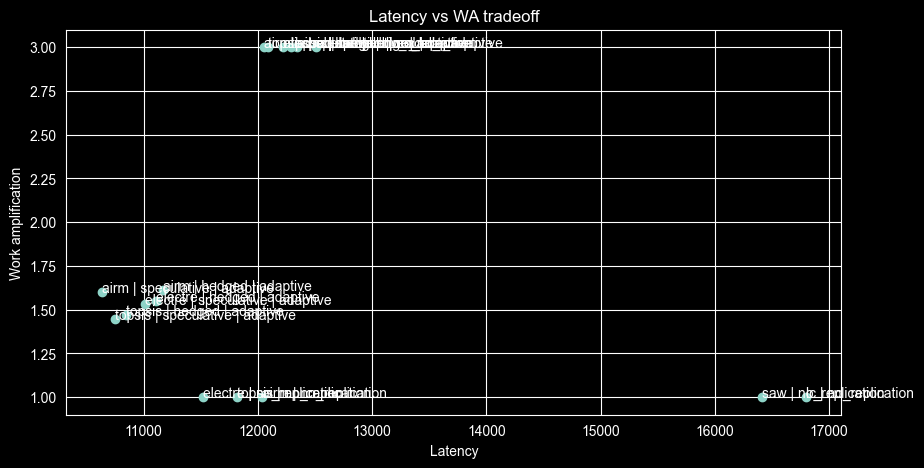

In [164]:
tradeoff = latency_stats.merge(
    wa_stats,
    left_index=True,
    right_index=True
)

plt.scatter(tradeoff["mean_x"], tradeoff["mean_y"])

for name, row in tradeoff.iterrows():
    plt.text(row["mean_x"], row["mean_y"], name)

plt.xlabel("Latency")
plt.ylabel("Work amplification")

plt.title("Latency vs WA tradeoff")

plt.show()

# CPU / MEM

In [165]:
socket_dist = (
    df
    .groupby(["method", "winner_socket"])
    .size()
    .reset_index(name="count")
)

socket_dist.head()

,method,winner_socket,count
0,airm | hedged | adaptive,,150
1,airm | hedged | adaptive,192.168.68.50_GQW_8001,6
2,airm | hedged | adaptive,192.168.68.50_GQW_8002,11
3,airm | hedged | adaptive,192.168.68.50_GQW_8003,71
4,airm | hedged | adaptive,192.168.68.50_GQW_8004,10


In [166]:
balance = (
    socket_dist
    .groupby("method")["count"]
    .agg(
        mean="mean",
        std="std"
    )
)

balance["cv"] = balance["std"] / balance["mean"]

balance.sort_values("cv")

,mean,std,cv
method,,,
electre | speculative | adaptive,30.303030,34.727047,1.145993
airm | hedged | adaptive,23.809524,32.348135,1.358622
topsis | speculative | adaptive,23.809524,32.905065,1.382013
topsis | hedged | adaptive,25.000000,35.316881,1.412675
airm | speculative | adaptive,25.000000,38.283691,1.531348
electre | hedged | adaptive,25.000000,39.134220,1.565369
airm | speculative | no_adaptive,23.255814,67.675026,2.910026
electre | speculative | no_adaptive,23.255814,68.926149,2.963824
topsis | speculative | no_adaptive,23.255814,71.129691,3.058577


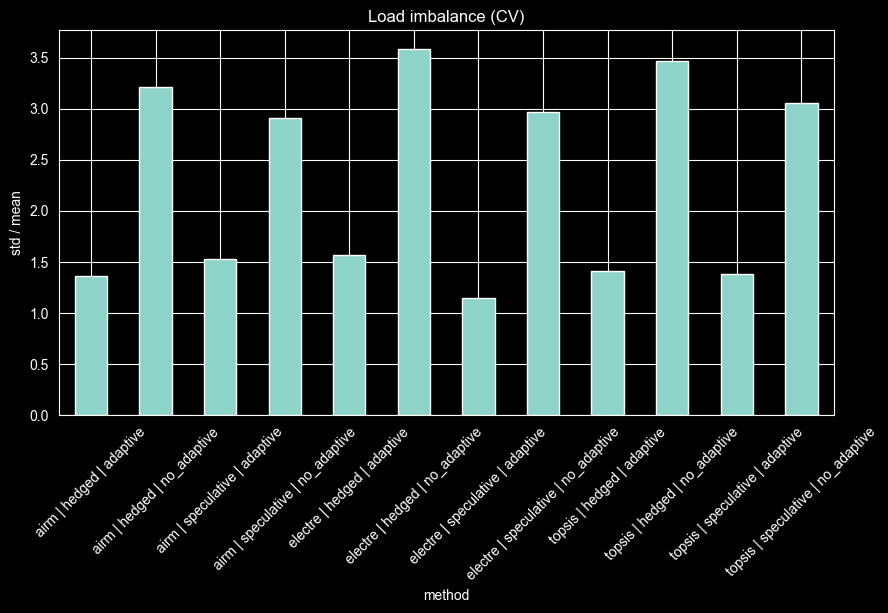

In [167]:
balance["cv"].plot(kind="bar")

plt.title("Load imbalance (CV)")
plt.ylabel("std / mean")

plt.xticks(rotation=45)

plt.show()

In [168]:
lat_by_group = (
    df
    .groupby("group")["latency_ms"]
    .mean()
)

lat_by_group

group
balancer_only              13715.555297
replication_adaptive       10919.151872
replication_no_adaptive    12250.419197
Name: latency_ms, dtype: float64

In [169]:
baseline = lat_by_group["balancer_only"]

rep_no = lat_by_group["replication_no_adaptive"]

rep_ad = lat_by_group["replication_adaptive"]

print("Replication improvement:",
      (baseline - rep_no) / baseline * 100)

Replication improvement: 10.682295165260513


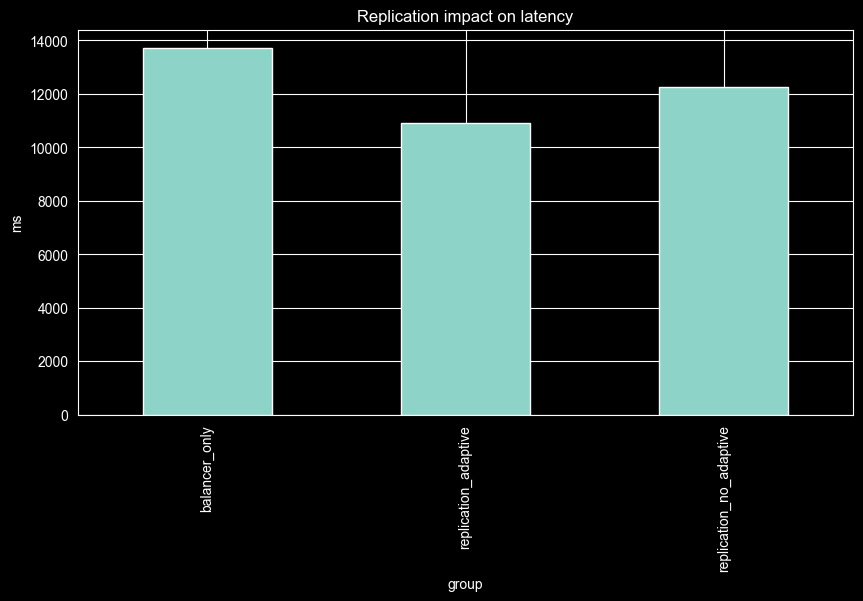

In [170]:
lat_by_group.plot(kind="bar")

plt.title("Replication impact on latency")

plt.ylabel("ms")

plt.show()

# Выгода адаптивности

In [171]:
wa_group = (
    df
    .groupby("group")["replicas"]
    .mean()
)

wa_group

group
balancer_only              1.000000
replication_adaptive       1.533833
replication_no_adaptive    3.000000
Name: replicas, dtype: float64

In [172]:
adaptive_gain = (
                        (wa_group["replication_no_adaptive"]
                         - wa_group["replication_adaptive"])

                        / wa_group["replication_no_adaptive"]

                ) * 100

print("Adaptive WA reduction:", adaptive_gain)

Adaptive WA reduction: 48.87222222222222


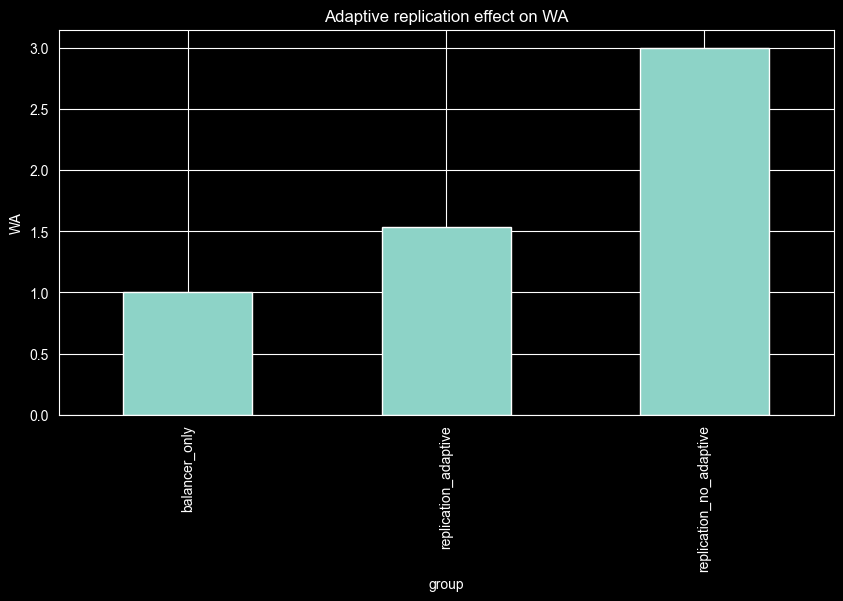

In [173]:
wa_group.plot(kind="bar")

plt.title("Adaptive replication effect on WA")

plt.ylabel("WA")

plt.show()

# CPU vs MEM Latency

In [174]:
df["is_cpu"] = df["endpoint"].str.startswith("cpu")

lat_cpu_mem = (

    df
    .groupby(["method","is_cpu"])["latency_ms"]
    .mean()
    .unstack()
)

lat_cpu_mem

is_cpu,False,True
method,,
airm | hedged | adaptive,11496.600645,10846.008655
airm | hedged | no_adaptive,12695.188942,12007.579321
airm | no_replication,12914.565001,11189.636384
airm | speculative | adaptive,10695.390246,10576.600576
airm | speculative | no_adaptive,12260.295658,11841.017796
electre | hedged | adaptive,11179.377905,11039.030313
electre | hedged | no_adaptive,12544.941926,12471.190732
electre | no_replication,12316.823018,10693.589000
electre | speculative | adaptive,11180.638898,10854.461037


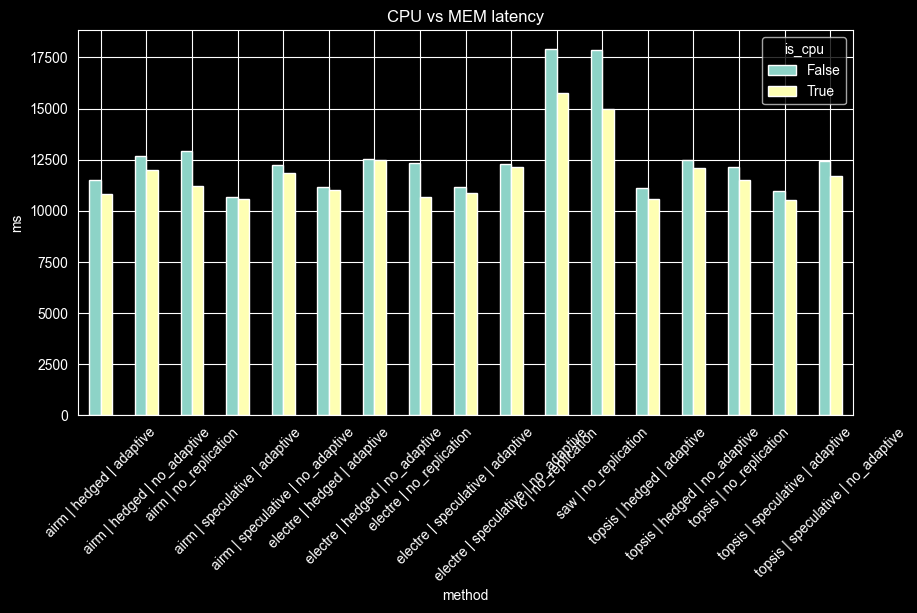

In [175]:
lat_cpu_mem.plot(kind="bar")

plt.title("CPU vs MEM latency")

plt.ylabel("ms")

plt.xticks(rotation=45)

plt.show()

In [176]:
best_mean = latency_stats["mean"].idxmin()
best_p95 = latency_stats["p95"].idxmin()
best_wa = wa_stats["mean"].idxmin()

print("Best mean latency:", best_mean)
print("Best p95 latency:", best_p95)
print("Best WA:", best_wa)

Best mean latency: airm | speculative | adaptive
Best p95 latency: airm | speculative | adaptive
Best WA: airm | no_replication
